Epoch	Train MSE	Test MSE
1	4122975335.58		3577768196.28
2	2963382795.12		2524364141.42
3	2227397649.87		1860524389.88
4	1720533586.67		1406744934.83
5	1356009695.56		1082997811.81
6	1086400693.93		845611933.77
7	882942749.41		668150046.28
8	727026883.68		533546259.36
9	606068392.49		430288581.39
10	511275495.85		350357400.84
11	436350857.93		288026482.55
12	376693302.34		239126372.14
13	328885872.34		200572438.32
14	290356346.46		170052231.11
15	259145908.09		145812699.38
16	233747919.07		126512093.40
17	212993397.60		111114927.97
18	195968339.74		98816278.75
19	181953186.17		88986457.43
20	170377955.28		81130087.73
21	160788626.08		74855509.51
22	152821706.52		69851687.53
23	146184827.48		65870636.69
24	140641819.15		62713944.13
25	136001153.34		60222362.49
26	132106934.74		58267724.47
27	128831837.60		56746625.62
28	126071537.72		55575462.97
29	123740301.02		54686520.25
30	121767472.46		54024865.50
31	120094669.19		53545882.61
32	118673527.97		53213300.11
33	117463890.31		52997611.67

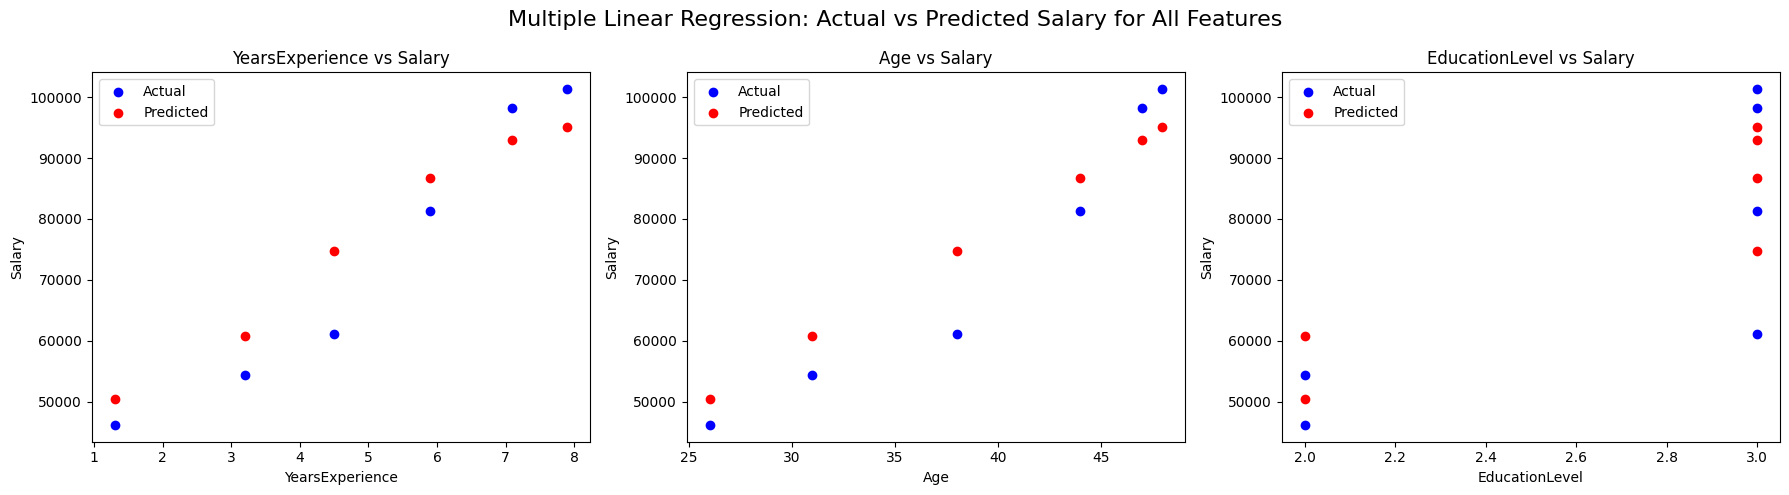

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error, r2_score

data = pd.DataFrame({
    'YearsExperience': [1.1, 1.3, 1.5, 2.0, 2.2, 2.9, 3.0, 3.2, 3.2, 3.7,
                        3.9, 4.0, 4.0, 4.1, 4.5, 4.9, 5.1, 5.3, 5.9, 6.0,
                        6.8, 7.1, 7.9, 8.2, 8.7, 9.0, 9.5, 9.6, 10.3, 10.5],
    'Age': [25, 26, 24, 28, 27, 30, 32, 31, 33, 34,
            35, 36, 36, 37, 38, 40, 41, 42, 44, 45,
            46, 47, 48, 49, 50, 51, 52, 53, 54, 55],
    'EducationLevel': [1, 2, 1, 2, 2, 3, 3, 2, 2, 3,
                       3, 3, 2, 2, 3, 3, 3, 3, 3, 3,
                       3, 3, 3, 3, 3, 3, 3, 3, 3, 3],
    'Salary': [39343, 46205, 37731, 43525, 39891, 56642, 60150, 54445, 64445, 57189,
               63218, 55794, 56957, 57081, 61111, 67938, 66029, 83088, 81363, 93940,
               91738, 98273, 101302, 113812, 109431, 105582, 116969, 112635, 122391, 121872]
    })

X = data[['YearsExperience', 'Age', 'EducationLevel']].values
y = data['Salary'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)


sgd_model = SGDRegressor(max_iter=1, tol=None, eta0=0.00001, random_state=12)

epochs = 100
print("Epoch\tTrain MSE\tTest MSE")
for epoch in range(1, epochs + 1):
    sgd_model.partial_fit(X_train, y_train)  # one pass over training data

    # Predictions
    y_train_pred = sgd_model.predict(X_train)
    y_test_pred = sgd_model.predict(X_test)

    # Compute MSE
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f"{epoch}\t{train_mse:.2f}\t\t{test_mse:.2f}")

print("\nFinal Coefficients:", sgd_model.coef_)
print("Final Intercept:", sgd_model.intercept_)

features = ['YearsExperience', 'Age', 'EducationLevel']
X_test_df = pd.DataFrame(X_test, columns=features)
y_test_pred = sgd_model.predict(X_test)


plt.figure(figsize=(18, 5))
for i, feature in enumerate(features):
    plt.subplot(1, 3, i + 1)
    plt.scatter(X_test_df[feature], y_test, color='blue', label='Actual')
    plt.scatter(X_test_df[feature], y_test_pred, color='red', label='Predicted')
    plt.xlabel(feature)
    plt.ylabel("Salary")
    plt.title(f"{feature} vs Salary")
    plt.legend()

plt.suptitle("Multiple Linear Regression: Actual vs Predicted Salary for All Features", fontsize=16)
plt.tight_layout()
plt.show()




Enter Employee Details:
Enter Years of Experience: 1.1
Enter Age: 25
Enter Education Level (1=High School, 2=Bachelor, 3=Master): 2

Predicted Salary: 48551.69
Enter Years of Experience: 2
Enter Age: 26
Enter Education Level (1/2/3): 3


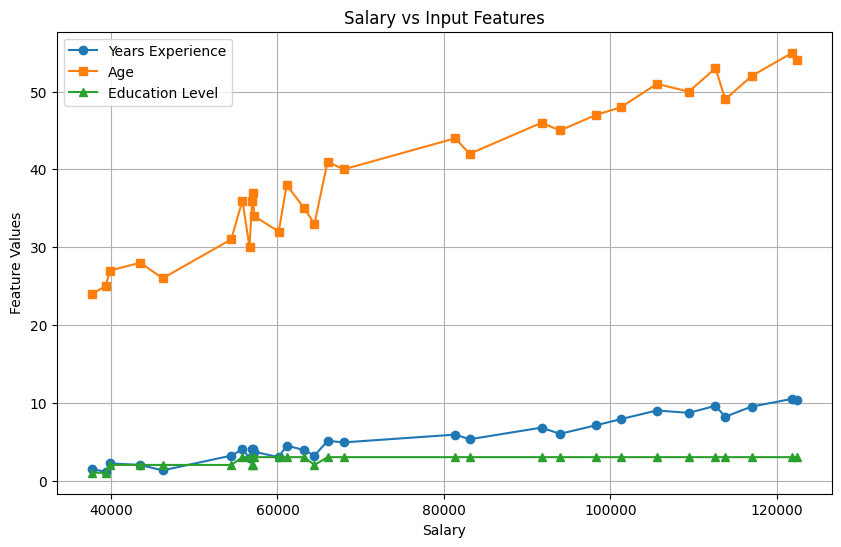

In [20]:

print("\nEnter Employee Details:")

years_exp = float(input("Enter Years of Experience: "))
age = int(input("Enter Age: "))
education = int(input("Enter Education Level (1=High School, 2=Bachelor, 3=Master): "))

# Create input array
user_data = np.array([[years_exp, age, education]])

# Predict salary
predicted_salary = sgd_model.predict(user_data)

print(f"\nPredicted Salary: {predicted_salary[0]:.2f}")

# User inputs
years_exp = float(input("Enter Years of Experience: "))
age = int(input("Enter Age: "))
education = int(input("Enter Education Level (1/2/3): "))

user_data = np.array([[years_exp, age, education]])
predicted_salary = sgd_model.predict(user_data)[0]
plt.figure(figsize=(10,6))

# Sort by Salary for a proper line graph
sorted_data = data.sort_values(by='Salary')

plt.plot(sorted_data['Salary'],
         sorted_data['YearsExperience'],
         marker='o',
         label='Years Experience')

plt.plot(sorted_data['Salary'],
         sorted_data['Age'],
         marker='s',
         label='Age')

plt.plot(sorted_data['Salary'],
         sorted_data['EducationLevel'],
         marker='^',
         label='Education Level')

plt.xlabel("Salary")
plt.ylabel("Feature Values")
plt.title("Salary vs Input Features")
plt.legend()
plt.grid(True)

plt.show()